# Retriever Evaluation Pipeline (Consolidated)

This notebook evaluates the performance of `dense`, `sparse`, `ensemble`, and `hybrid` retrievers.
It uses a simplified Python loop instead of LangGraph.

**Metrics:**
- Hit Rate@TopK
- NDCG@TopK
- Accuracy@Top1
- Relevance Score (LLM Judge 0-5)

In [36]:
import sys
import os
import random
import math
import asyncio
from typing import List, Dict, Any
from tabulate import tabulate
from sqlalchemy import text

# Ensure project root is in sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

from app.core.config import settings
from app.db.session import SessionLocal
from app.db.vector_db import (
    get_dense_retriever,
    get_sparse_retriever,
    get_ensemble_retriever,
    get_hybrid_retriever,
    get_dense_multi_query_retriever,
    get_multi_query_ensemble_retriever,
    get_hyde_retriever
)

## 1. Setup & Configuration

In [37]:
def get_llm(model="solar-pro2"):
    # Use solar-pro as configured
    return ChatUpstage(api_key=settings.UPSTAGE_API_KEY, model=model)

## 2. Helper Functions: Data Gen & Metrics

In [38]:
from langchain_core.output_parsers import ListOutputParser, StrOutputParser
# === Data Generation ===

def get_random_attractions(limit: int = 1):
    """
    Fetch random attractions from DB.
    """
    db = SessionLocal()
    try:
        query = text(
            """
            SELECT no, title, overview 
            FROM attractions 
            WHERE overview IS NOT NULL AND overview != '' 
            AND ST_Distance_Sphere(
                POINT(longitude, latitude), 
                POINT(:user_lng, :user_lat)
            ) <= (:radius_km * 1000)
            ORDER BY RAND() 
            LIMIT :limit
            """
        )
        result = db.execute(query, {"limit": limit, "user_lat": 37.5666, "user_lng": 126.9780, "radius_km": 3}).fetchall()
        return [
            {"no": row.no, "title": row.title, "overview": row.overview}
            for row in result
        ]
    finally:
        db.close()

def generate_synthetic_query(category: str, k=5) -> str:
    """
    Generate a search query based on overview using LLM.
    """
    llm = get_llm()
    prompt = ChatPromptTemplate.from_messages([
        ("system", """
        [역할]
        당신은 관광지를 찾고싶은 여행객입니다.
        제시된 [카테고리]를 방문하고 싶어하는 사용자들이 던질 법한 질문을 {k}개 생성하세요.
        
        [지침]
        1. 질문은 친구나 AI에게 말하는 듯한 자연스러운 구어체여야 합니다.
        2. 특정 장소 이름이나 특정 지역명(예: 종로, 시청)은 절대 포함하지 마세요.
        3. 각 질문은 서로 다른 상황(예: 혼자, 가족과, 데이트, 비즈니스 등)을 가정하여 다양하게 만드세요.
        4. 답변은 오직 질문 내용만 출력하며, 각 질문은 줄바꿈으로 구분하세요.      
        5. 절대로 부가적인 설명이나 번호등을 붙이지말고 정확히 5줄이 나오도록 출력하세요.  
        [카테고리]: {category}
        """),
    ])

    # [수정] StrOutputParser를 사용하여 결과를 문자열로 받음
    chain = prompt | llm | StrOutputParser()
    
    print(f"✍️ {category} 관련 가상 질문 생성 중...")
    raw_response = chain.invoke({"category": category, "k": k})
    
    # 줄바꿈으로 쪼개고 빈 줄은 제거하여 리스트 반환
    queries = [q.strip() for q in raw_response.strip().split('\n') if q.strip()]
    return queries[:k] # 정확히

def check_hit_rate(ground_truth_id: int, retrieved_docs: list) -> int:
    for doc in retrieved_docs:
        retrieved_id = doc.metadata.get("no")
        if str(retrieved_id) == str(ground_truth_id):
            return 1
    return 0

def calculate_ndcg(ground_truth_id: int, retrieved_docs: list) -> float:
    for i, doc in enumerate(retrieved_docs):
        retrieved_id = doc.metadata.get("no")
        if str(retrieved_id) == str(ground_truth_id):
            rank = i + 1
            return 1.0 / math.log2(rank + 1)
    return 0.0

def calculate_top1_accuracy(ground_truth_id: int, retrieved_docs: list) -> int:
    if not retrieved_docs:
        return 0
    top_doc = retrieved_docs[0]
    retrieved_id = top_doc.metadata.get("no")
    if str(retrieved_id) == str(ground_truth_id):
        return 1
    return 0

## 3. Main Evaluation Logic

In [39]:
async def run_single_evaluation(query: str, gt_id: int, k: int=5):
    """
    Runs 4 retrievers and evaluates metrics for each.
    Returns a dict of results.
    """
    # 1. Initialize Retrievers
    # Note: VectorStore creation is cached or cheap enough in this context
#    filter = create_geo_radius_filter(lat=37.5666, lon=126.9780, radius_km=3)
    retrievers = {
        "dense": get_dense_retriever(k=k),
        "sparse": get_sparse_retriever(k=k),
        "ensemble": get_ensemble_retriever(k=k),
        "hybrid": get_hybrid_retriever(k=k),
        "multi_query_dense": get_dense_multi_query_retriever(k=k, llm=get_llm()),
        "multi_query_ensemble": get_multi_query_ensemble_retriever(k=k, llm=get_llm()),
    }
    
    results = {}
    
    for name, retriever in retrievers.items():
        # Retrieve (async invoke if possible, else invoke)
        docs = await retriever.ainvoke(query)
        
        # Metrics
        hit = check_hit_rate(gt_id, docs)
        ndcg = calculate_ndcg(gt_id, docs)
        acc = calculate_top1_accuracy(gt_id, docs)
        
        # LLM Judge on Top-1
        if docs:
            top_doc = docs[0]
            content = f"Title: {top_doc.metadata.get('title')}\nOverview: {top_doc.metadata.get('overview')}"
            #eval_res = evaluate_relevance(query, content)
            #score = eval_res.score
        else:
            score = 0
            
        results[name] = {
            "hit_rate": hit,
            "ndcg": ndcg,
            "accuracy": acc,
            #"score": score
        }
        
    return results

## 4. Run Experiment

In [40]:
# import logging

# logging.basicConfig()
# logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

In [41]:
num_samples = 20
#attractions = get_random_attractions(limit=num_samples)
categories = ["관광지","문화시설","축제공연행사","여행코스","레포츠","숙박","쇼핑","음식점"]
dataset = []

print(f"Generated {len(categories)} samples:")
for category in categories:
    query = generate_synthetic_query(category, 5)
    dataset.extend(query)
    # dataset.append({
    #     "query": query,
    #     "target_category": category,
    #     #"ground_truth_id": attr["no"],
    #     #"ground_truth_overview": attr["overview"],
    #     #"title": attr["title"]
    # })
    print(f"- [{category}] Q: {query}")

print(f"최종 데이터 : {dataset}")
# # Aggregator
# aggregated_results = {
#     key: {"hit_rate": 0, "ndcg": 0, "accuracy": 0}
#     for key in ["dense", "sparse", "ensemble", "hybrid", "multi_query_dense", "multi_query_ensemble"]
# }

# print("\n🚀 Starting Evaluation Loop...")

# # Main Loop
# for i, data in enumerate(dataset):
#     print(f"[{i+1}/{num_samples}] Processing: {data['query']}")
    
#     # Run Evaluation
#     sample_results = await run_single_evaluation(data["query"], data["ground_truth_id"])
    
#     # Aggregate
#     for method, metrics in sample_results.items():
#         for metric_name, value in metrics.items():
#             aggregated_results[method][metric_name] += value

# # Display Summary
# summary = []
# for method, totals in aggregated_results.items():
#     avg_hit = totals["hit_rate"] / num_samples
# #    avg_score = totals["score"] / num_samples
#     avg_ndcg = totals["ndcg"] / num_samples
#     avg_acc = totals["accuracy"] / num_samples
#     summary.append([method, avg_hit, avg_ndcg, avg_acc])

# print("\n📊 Evaluation Results:")
# print(tabulate(summary, headers=["Retriever", "Hit Rate@5", "NDCG", "Accuracy@1"], tablefmt="grid"))

Generated 8 samples:
✍️ 관광지 관련 가상 질문 생성 중...
- [관광지] Q: ['혼자 여행할 때 안전하게 다닐 수 있는 관광지 추천해줄래?', '가족과 함께 가기 좋은 실내 관광지 어디가 있을까?', '연인과 분위기 좋은 카페에서 사진 찍기 좋은 관광지 알고 있어?', '비즈니스 미팅 후 잠깐 들려서 쉴 수 있는 관광지가 있을까?', '아이들이 체험 활동하기 좋은 관광지 좀 알려줘.']
✍️ 문화시설 관련 가상 질문 생성 중...
- [문화시설] Q: ['혼자 가기 좋은 조용한 박물관이나 갤러리 있을까요?', '아이들과 함께 체험할 수 있는 문화시설은 어디가 좋을까요?', '데이트 코스로 분위기 있는 공연장이나 전시관이 필요해요!', '비즈니스 미팅 후 여유롭게 둘러볼 만한 문화시설이 있을까요?', '할머니와 함께 가기 편한 전통 공예 체험장이 있을까요?']
✍️ 축제공연행사 관련 가상 질문 생성 중...
- [축제공연행사] Q: ['가족과 함께 즐길 만한 축제 중에 아이들도 좋아할 만한 공연이 있을까요?', '혼자서도 부담 없이 즐길 수 있는 소규모 공연 행사가 있을까요?', '데이트 코스로 좋을 만한 야간 특별 공연이나 이벤트가 있는지 궁금해요.', '출장 중에 잠깐 시간을 내서 볼 만한 전통 공연이나 흥미로운 행사가 있을까요?', '연말 분위기를 느끼며 참여할 수 있는 크리스마스 테마 공연이나 이벤트가 있을까요?']
✍️ 여행코스 관련 가상 질문 생성 중...
- [여행코스] Q: ['혼자 여행할 때 가볼 만한 여행코스가 있을까요?', '가족들과 함께 즐길 수 있는 여행코스를 추천해 주세요.', '데이트 코스로 좋은 여행지가 있을까요?', '출장 중 잠깐 들러볼 만한 여행코스가 있을지 궁금해요.', '친구와 함께 걷기 좋은 여행코스가 있을까요?']
✍️ 레포츠 관련 가상 질문 생성 중...
- [레포츠] Q: ['혼자 갈 만한 스릴 넘치는 액티비티가 있을까요?', '아이들과 함께 체험할 수 있는 안전한 레포츠는 뭐가 있을까요?', 

In [ ]:
import pandas as pd
import asyncio
from datasets import Dataset
from tabulate import tabulate
from ragas import evaluate
from ragas.run_config import RunConfig
from langchain_openai import ChatOpenAI
from ragas.metrics import AspectCritic
from app.db.filters import create_geo_radius_filter
from langchain_upstage.embeddings import UpstageEmbeddings
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
filter = create_geo_radius_filter(lat=37.5666, lon=126.9780, radius_km=5)

# 1. 평가자 설정 (Upstage Solar 모델 및 임베딩)
embeddings = UpstageEmbeddings(api_key=settings.UPSTAGE_API_KEY, model="embedding-query")
evaluator_llm = get_llm("solar-mini") # solar-pro2

# 1. 카테고리 일치성 
category_alignment = AspectCritic(
    name="category_alignment",
    definition="""
    [역할]
    당신은 검색된 장소의 성격이 사용자의 의도와 부합하는지 검증하는 품질 평가사입니다.

    [평가 기준]
    1. 사용자의 질문에서 요구하는 '장소의 유형'이나 '업종(카테고리)'을 명확히 파악하세요.
    2. 제공된 문서(Context)에 설명된 장소의 주요 기능, 서비스, 실질적인 성격이 사용자의 요구 사항과 일치하는지 비교하세요.
    3. 단순히 이름이 비슷하거나 인접한 분야가 아니라, 사용자가 해당 장소에 방문했을 때 기대하는 핵심 목적을 달성할 수 있는 곳이어야 합니다.

    [점수 부여]
    - 질문의 카테고리 의도와 장소의 실질적인 성격이 완벽히 일치하면 1을 부여합니다.
    - 장소의 성격이 다르거나, 사용자의 의도를 충족하기에 부적절한 유형의 장소라면 0을 부여합니다.
    """,
    strictness=1
)


# 2. 분위기 및 조건 관련성 (추상적 요구사항 체크)
vibe_relevance = AspectCritic(
    name="vibe_relevance",
    definition="""
    [역할]
    당신은 사용자의 요구사항을 깊이 이해하고, 검색된 장소가 사용자의 의도를 실질적으로 만족시킬 수 있는지 판단하는 품질 평가사입니다.
    
    [채점 가이드라인]
    1. 맥락적 수용: 질문자가 요구한 분위기(예: 조용한, 현대적인)나 서비스 성격(예: 친절한)이 텍스트에 직접 등장하지 않더라도, 장소의 유형이나 설명된 특징(예: '한적한 골목에 위치', '1:1 맞춤 서비스')을 통해 충분히 유추 가능하다면 1점을 부여하세요.
    2. 복합 조건의 유연성: '쇼핑 AND 업무'처럼 두 가지 조건을 요구했을 때, 한 쪽이 주된 기능이고 다른 쪽이 보조적으로 가능해 보인다면(예: 대형 쇼핑몰 내의 라운지나 카페 시설) 사용자의 경험적 측면에서 1점을 부여할 수 있습니다.
    3. 사용자 경험(UX) 중심: 단순히 텍스트 일치 여부를 따지는 것이 아니라, "사용자가 이 추천을 받았을 때 실망하지 않고 목적을 달성할 수 있겠는가?"를 최우선으로 고려하세요.

    [통과 기준: 1점 부여]
    - 요구한 분위기와 직접 일치하는 단어가 있는 경우.
    - 장소의 묘사를 통해 해당 분위기나 조건이 자연스럽게 연상되는 경우.
    - 복합적인 목적(쇼핑/업무/문화) 중 핵심 목적을 확실히 충족하며, 나머지도 가능성이 열려있는 경우.
    
    [탈락 기준: 0점 부여]
    1. 명백한 속성 상반: 사용자의 요구와 물리적으로 반대되는 경우 (예: '조용한' 곳을 찾는데 '공연 위주의 시끌벅적한' 장소인 경우).
    2. 무관한 정보: 장소 설명이 사용자의 요구 조건과 아예 상관없는 정보(단순 주소, 관련 없는 상품 정보 등)만 담고 있어 판단 자체가 불가능한 경우.
    """,
    strictness=1
)

async def run_ragas_only_evaluation(dataset, k=5):
    retriever_names = ["dense", "ensemble", "hyde"]# "sparse", "multi_query_dense", "ensemble", "hyde"]
    
    # [최적화 1] 리트리버 초기화를 루프 외부에서 한 번만 수행
    retrievers = {
        "dense": get_dense_retriever(k=k, filter=filter),
        # "sparse": get_sparse_retriever(k=k, filter=filter),
        # "multi_query_dense": get_dense_multi_query_retriever(k=k, llm=get_llm(), filter=filter),
        "ensemble": get_ensemble_retriever(k=k, dense_weight=0.7, sparse_weight=0.3, filter=filter),
        "hyde": get_hyde_retriever(k=k, llm=get_llm(model="solar-pro2"), filter=filter),
    }

    ragas_data_collections = {name: [] for name in retriever_names}

    print(f"🚀 총 {len(dataset)}개 샘플 검색 시작 (병렬 처리)...")

    for data in dataset:
        query = data
     #   gt_content = data["ground_truth_overview"]
        
        # [최적화 2] asyncio.gather를 사용하여 5개의 리트리버를 동시에 실행
        tasks = [retrievers[name].ainvoke(query) for name in retriever_names]
        results = await asyncio.gather(*tasks)

        for name, docs in zip(retriever_names, results):
            combined_contexts = [
                f"장소명: {doc.metadata.get('title', 'N/A')}\n내용: {doc.metadata.get('overview', '')}" 
                for doc in docs
            ]
            ragas_data_collections[name].append({
                "user_input": query,
                "retrieved_contexts": combined_contexts,
               # "reference": gt_content
            })

    # === Ragas 점수 계산 ===
    all_results_dfs = []
    for name in retriever_names:
        print(f"⚖️ {name} 리트리버 LLM 평가 중...")
        ragas_ds = Dataset.from_list(ragas_data_collections[name])
        
        # [최적화 3] max_workers를 4~8 정도로 상향 조정 (API Rate Limit에 따라 조절)
        result = evaluate(
            dataset=ragas_ds,
            metrics=[category_alignment, vibe_relevance],
            llm=evaluator_llm,
            run_config=RunConfig(timeout=180, max_retries=20, max_workers=10) 
        )
        
        res_df = result.to_pandas()
        res_df['retriever_name'] = name
        all_results_dfs.append(res_df)

    # === 3. 모든 결과 합치기 및 통계 계산 ===
    total_df = pd.concat(all_results_dfs, ignore_index=True)

    # 4. 정량 지표 요약
    summary_stats = total_df.groupby('retriever_name').agg({
        'category_alignment': 'mean',
        'vibe_relevance': 'mean'
    }).reset_index()

    # 5. 종합 점수 계산
    summary_stats['Total_Score'] = (summary_stats['category_alignment'] * 0.7) + (summary_stats['vibe_relevance'] * 0.3)
    summary_stats = summary_stats.sort_values(by='Total_Score', ascending=False)

    print("\n📊 리트리버별 정량 성능 비교표:")
    print(tabulate(summary_stats, headers='keys', tablefmt='psql', showindex=False))
    
    return total_df, summary_stats

🚀 총 40개 샘플 검색 시작 (병렬 처리)...
⚖️ dense 리트리버 LLM 평가 중...


Evaluating: 100%|██████████| 80/80 [03:07<00:00,  2.34s/it]


⚖️ ensemble 리트리버 LLM 평가 중...


Evaluating:  70%|███████   | 56/80 [03:39<02:02,  5.11s/it]Exception raised in Job[23]: TimeoutError()
Exception raised in Job[24]: TimeoutError()
Evaluating: 100%|██████████| 80/80 [05:40<00:00,  4.26s/it]



📊 리트리버별 정량 성능 비교표:
+------------------+----------------------+------------------+---------------+
| retriever_name   |   category_alignment |   vibe_relevance |   Total_Score |
|------------------+----------------------+------------------+---------------|
| dense            |             0.925    |         1        |      0.9475   |
| ensemble         |             0.769231 |         0.972973 |      0.830353 |
+------------------+----------------------+------------------+---------------+


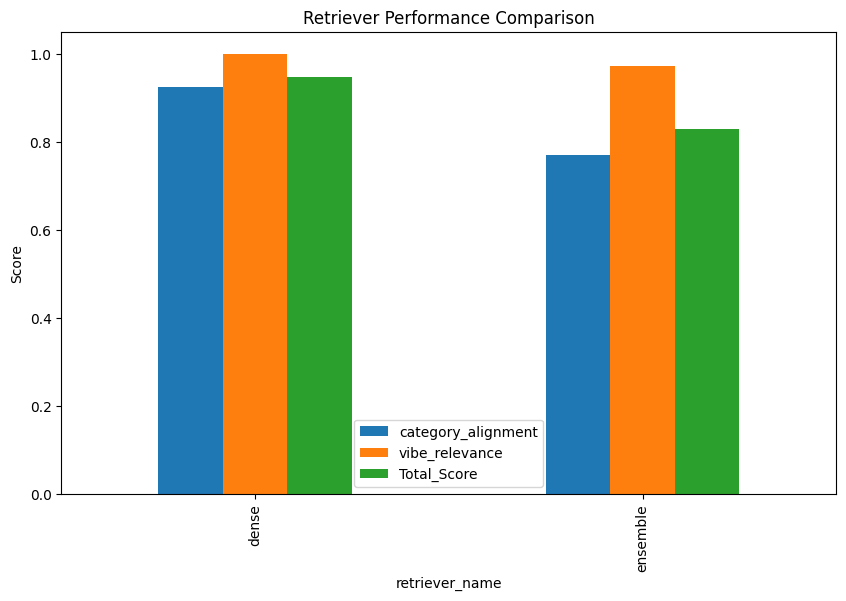

In [43]:
# 간단한 막대 그래프 출력 예시
import matplotlib.pyplot as plt
total_df, summary_stats = await run_ragas_only_evaluation(dataset,k=num_samples)

summary_stats.set_index('retriever_name')[['category_alignment', 'vibe_relevance', 'Total_Score']].plot(kind='bar', figsize=(10, 6))
plt.title("Retriever Performance Comparison")
plt.ylabel("Score")
plt.show()

In [9]:
# await run_ragas_only_evaluation(dataset)

In [10]:
# failure_cases = total_df[
#     (total_df['category_alignment'] == 1) | 
#     (total_df['vibe_relevance'] > 0.5)
# ]

# # 어떤 리트리버에서 어떤 질문이 실패했는지 저장
# failure_cases[['retriever_name', 'user_input', 'retrieved_contexts', 'category_alignment', 'vibe_relevance']].to_csv("success_analysis.csv", index=False)

# print(f"총 {len(failure_cases)}개의 실패 사례를 failure_analysis.csv로 저장했습니다.")